# 2장 1강: AARRR 프레임워크 개요와 단계별 분석 목적 — 실습문제

## 실습 목표

- Ravenstack의 사용자 여정을 AARRR 5단계로 구분할 수 있다.
- 각 단계의 분석 목적과 활용 가능한 데이터를 연결할 수 있다.
- 이벤트 로그의 사용자·행동·시점·속성 컬럼을 구분할 수 있다.
- 분석 질문에 맞게 퍼널·코호트·세그멘테이션 분석을 선택할 수 있다.
- 그룹별 Activation 지표를 비교하여 점검 대상을 찾을 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 기업 고객에게 구독형 소프트웨어를 제공하는 B2B SaaS 서비스입니다.

Ravenstack의 AARRR 단계는 다음과 같이 연결할 수 있습니다.

| 단계 | Ravenstack에서의 의미 | 활용 데이터 예시 |
|---|---|---|
| Acquisition | 고객사가 유입되어 가입함 | 가입일, 유입 경로 |
| Activation | 구독 후 제품 기능을 처음 사용함 | 기능 사용 기록 |
| Retention | 제품 사용과 구독을 계속 유지함 | 반복 사용 기록, 이탈 여부 |
| Referral | 기존 고객이 다른 고객을 추천함 | 추천 전송·추천 가입 이벤트 |
| Revenue | 유료 구독에서 반복 매출이 발생함 | MRR, 요금제 |

> 제공된 데이터에는 고객 추천 행동을 직접 기록한 이벤트가 없습니다. `referral_source`는 고객의 유입 경로이며, 기존 고객이 추천 행동을 했다는 사실을 직접 보여주는 Referral 이벤트와는 구분해야 합니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `signup_date`, `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. `feature_usage`에서 이벤트 식별자인 `usage_id`의 중복 개수를 확인하세요.
7. 기능별 이벤트 기록 수와 `usage_count`의 기초 통계량을 확인하세요.

In [5]:
# 실습 준비 코드를 작성하세요.
# ----------------------------------------------------
# 1. 필요한 라이브러리 불러오기
# ----------------------------------------------------
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 2. 세 CSV 파일 각각 불러오기
# ----------------------------------------------------
# 실행 환경의 파일 경로에 맞게 지정하세요. (예: 'data/ravenstack_accounts.csv')
accounts = pd.read_csv("ravenstack_accounts.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")

# ----------------------------------------------------
# 3. 각 데이터의 행과 열 개수, 상위 5개 행 확인
# ----------------------------------------------------
print("=== 1. Accounts Shape & Head ===")
print("Shape:", accounts.shape)
display(accounts.head())

print("\n=== 2. Subscriptions Shape & Head ===")
print("Shape:", subscriptions.shape)
display(subscriptions.head())

print("\n=== 3. Feature Usage Shape & Head ===")
print("Shape:", feature_usage.shape)
display(feature_usage.head())

# ----------------------------------------------------
# 4. 분석 대상 컬럼의 자료형과 결측치 개수 확인
# ----------------------------------------------------
print("\n=== Accounts Info & Missing Values ===")
print(accounts.info())
print("\n[Accounts 결측치]")
print(accounts.isnull().sum())

print("\n=== Subscriptions Info & Missing Values ===")
print(subscriptions.info())
print("\n[Subscriptions 결측치]")
print(subscriptions.isnull().sum())

print("\n=== Feature Usage Info & Missing Values ===")
print(feature_usage.info())
print("\n[Feature Usage 결측치]")
print(feature_usage.isnull().sum())

# ----------------------------------------------------
# 5. 날짜 컬럼 날짜형(datetime) 변환
# ----------------------------------------------------
# accounts 가입일
accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])

# subscriptions 시작일/종료일
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])

# feature_usage 기능 사용일
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

print("\n변환 후 날짜 컬럼 타입 확인:")
print(f"- accounts['signup_date']: {accounts['signup_date'].dtype}")
print(f"- subscriptions['start_date']: {subscriptions['start_date'].dtype}")
print(f"- subscriptions['end_date']: {subscriptions['end_date'].dtype}")
print(f"- feature_usage['usage_date']: {feature_usage['usage_date'].dtype}")

# ----------------------------------------------------
# 6. feature_usage에서 이벤트 식별자(usage_id) 중복 개수 확인
# ----------------------------------------------------
duplicate_usage_ids = feature_usage["usage_id"].duplicated().sum()
print(f"\nfeature_usage 내 usage_id 중복 건수: {duplicate_usage_ids:,}건")

# ----------------------------------------------------
# 7. 기능별 이벤트 기록 수와 usage_count의 기초 통계량 확인
# ----------------------------------------------------
print("\n=== 기능(feature_name)별 이벤트 기록 수 (상위 10개) ===")
feature_record_counts = feature_usage["feature_name"].value_counts()
display(feature_record_counts.head(10))

print("\n=== usage_count 컬럼 기초 통계량 ===")
display(feature_usage["usage_count"].describe())

=== 1. Accounts Shape & Head ===
Shape: (500, 10)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True



=== 2. Subscriptions Shape & Head ===
Shape: (5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True



=== 3. Feature Usage Shape & Head ===
Shape: (25000, 8)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



=== Accounts Info & Missing Values ===
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB
None

[Accounts 결측치]
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

=== Subscriptions Info & Missing Valu

feature_name
feature_12    659
feature_32    659
feature_6     655
feature_17    651
feature_34    650
feature_26    649
feature_36    648
feature_31    644
feature_20    643
feature_24    643
Name: count, dtype: int64


=== usage_count 컬럼 기초 통계량 ===


count    25000.000000
mean        10.021000
std          3.143729
min          0.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         26.000000
Name: usage_count, dtype: float64

---

## 필수 1. Ravenstack의 AARRR 지표 지도 만들기

### 문제 1-1. 데이터에서 확인 가능한 단계별 대표 지표 계산하기

#### 문제 설명

Ravenstack의 세 테이블을 이용하여 AARRR 단계별 대표 지표를 계산하고, 제공된 데이터만으로 직접 측정하기 어려운 단계도 확인하세요.

이번 문제에서는 다음 기준을 사용합니다.

- Acquisition: 가입한 고유 고객사 수
- Activation: 전체 구독 중 기능 사용 기록이 한 번 이상 있는 구독의 비율
- Retention: 전체 구독 중 현재 `churn_flag`가 `False`인 구독의 비율
- Referral: 제공된 데이터로 직접 계산할 수 없음
- Revenue: 종료일이 없고 체험 구독이 아닌 현재 활성 유료 구독의 MRR 합계

> 여기에서 Retention은 학습을 위한 간단한 대리 지표입니다. 특정 기간 후 다시 사용한 비율을 계산한 정식 리텐션과는 다릅니다.

#### 요구사항

1. 가입한 고유 고객사 수를 `acquired_accounts`로 계산하세요.
2. 기능 사용 기록이 있는 고유 구독 수를 전체 구독 수로 나누어 `activation_rate`를 계산하세요.
3. `churn_flag`가 `False`인 구독의 비율을 `non_churned_rate`로 계산하세요.
4. 종료일이 없고 체험 구독이 아닌 구독의 MRR 합계를 `current_paid_mrr`로 계산하세요.
5. 네 지표를 알아보기 쉬운 형식으로 출력하세요.
6. 각 지표를 AARRR 단계와 연결하고 분석 목적을 설명하세요.
7. Referral 단계를 직접 측정하려면 어떤 이벤트가 추가로 필요한지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 기록이 있는 구독 비율은 어느 AARRR 단계와 연결되나요?  
**Q2.** `non_churned_rate`를 정식 리텐션율과 동일하게 보면 안 되는 이유는 무엇인가요?  
**Q3.** `referral_source`만으로 Referral 행동을 직접 측정할 수 있나요?  
**Q4.** MRR은 어느 AARRR 단계와 연결되나요?

#### 제출 결과

- AARRR 단계별 대표 지표 계산 코드와 결과
- 각 지표의 단계 및 분석 목적
- Referral 측정에 필요한 이벤트 제안
- Q1~Q4 답변

In [2]:
# 필수 1 코드를 작성하세요.

### 필수 1 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 필수 2. 요금제별 Activation 지표 비교하기

### 문제 2-1. 2024년 12월 제품 활성률을 요금제별로 비교하기

#### 문제 설명

프로덕트팀은 다음 질문에 답하려고 합니다.

> 2024년 12월에 어떤 요금제의 제품 활성률이 상대적으로 낮은가?

이 질문은 사용자를 요금제별로 나누어 비교하므로 **세그멘테이션 분석**에 해당하며, AARRR 중 Activation 단계를 살펴봅니다.

이번 실습에서 제품 활성률은 다음과 같이 정의합니다.

> 12월 제품 활성 유료 구독 수 ÷ 12월 이용 가능 유료 구독 수

#### 요구사항

1. 2024년 12월의 시작일과 마지막 날을 설정하세요.
2. 12월에 이용 가능한 유료 구독을 `eligible_dec`에 저장하세요.
3. 12월에 기능을 사용한 구독 ID를 `active_subscription_ids`로 준비하세요.
4. `eligible_dec`에 `is_product_active` 컬럼을 만드세요.
5. `plan_tier`별로 다음 값을 집계하여 `plan_activation`을 만드세요.
   - 이용 가능 유료 구독 수
   - 제품 활성 유료 구독 수
   - 제품 활성률
6. 제품 활성률이 낮은 순서로 정렬하고 백분율로 출력하세요.
7. 가장 낮은 요금제를 찾아 개선을 위해 추가로 확인할 내용을 제안하세요.
8. 이 질문에 세그멘테이션 분석이 적절한 이유를 설명하세요.

#### 해석 질문

**Q1.** 이 분석은 AARRR 중 어느 단계에 해당하나요?  
**Q2.** 어떤 분석 기법을 사용했으며, 그 이유는 무엇인가요?  
**Q3.** 제품 활성률이 가장 낮은 요금제는 무엇인가요?  
**Q4.** 해당 요금제에서 추가로 어떤 데이터를 확인하면 좋을까요?

#### 제출 결과

- `plan_activation` 집계 코드와 결과
- AARRR 단계와 분석 기법
- 우선 점검할 요금제
- 추가 확인 데이터
- Q1~Q4 답변

In [3]:
# 필수 2 코드를 작성하세요.

### 필수 2 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 Activation 지표 비교하기

#### 문제 설명

프로덕트팀은 2024년 12월 제품 활성률이 월간 결제 구독과 연간 결제 구독에서 다르게 나타나는지 확인하려고 합니다.

> 이 과제는 필수 2의 요금제별 세그멘테이션을 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. 필수 2에서 만든 `eligible_dec`과 `is_product_active`를 사용하세요.
2. `billing_frequency`별로 다음 값을 집계하여 `billing_activation`을 만드세요.
   - 이용 가능 유료 구독 수
   - 제품 활성 유료 구독 수
   - 제품 활성률
3. 제품 활성률이 낮은 순서로 정렬하고 백분율로 출력하세요.
4. 제품 활성률이 더 낮은 결제 주기를 찾으세요.
5. 해당 그룹을 우선 점검 대상으로 정하고 추가로 확인할 내용을 한 가지 제안하세요.
6. 이 분석의 AARRR 단계와 분석 기법을 설명하세요.

#### 해석 질문

**Q1.** 제품 활성률이 더 낮은 결제 주기는 무엇인가요?  
**Q2.** 이 분석은 어떤 AARRR 단계와 분석 기법에 해당하나요?  
**Q3.** 두 그룹의 제품 활성률 차이만으로 결제 주기가 낮은 활성의 원인이라고 결론 내릴 수 있나요?

**Q4.** 퍼널 분석·코호트 리텐션 분석·세그멘테이션을 표로 정리하세요. 각 분석의 계산 또는 분류 원리, 해결하려는 분석 질문, 관련 AARRR 단계를 설명하세요. 전환율·이탈률의 분모, 코호트의 시작 기준과 경과 기간, 세그먼트 분류 기준을 포함하세요.

#### 제출 결과

- `billing_activation` 집계 코드와 결과
- 우선 점검할 결제 주기
- 추가 확인 내용
- AARRR 단계와 분석 기법
- Q1~Q4 답변

=== 결제 주기별 Activation 지표 (billing_activation) ===


,eligible_subscriptions,active_subscriptions,activation_rate
billing_frequency,,,
annual,"1,968개",385개,19.56%
monthly,"2,013개",403개,20.02%



[활성률 최저 결제 주기]: annual (19.56%)


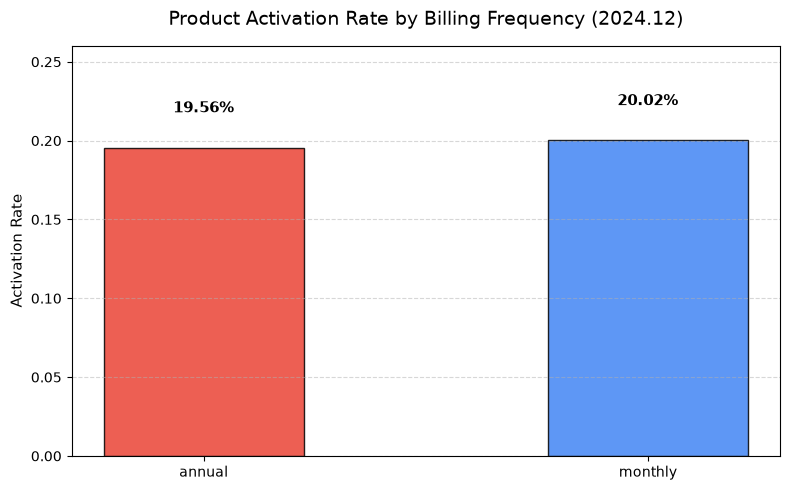

In [6]:
# 과제 1 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ====================================================
# [참고] 필수 2의 eligible_dec 및 is_product_active 준비
# (만약 이전 셀에서 이미 실행되었다면 아래 블록은 건너뛰어도 됩니다)
# ====================================================
# 1. 2024년 12월 유효 구독 조건:
#    start_date <= '2024-12-31' & (end_date.isna() | end_date >= '2024-12-01') & (is_trial == False)
target_month_start = pd.Timestamp("2024-12-01")
target_month_end = pd.Timestamp("2024-12-31")

eligible_mask = (
    (subscriptions["start_date"] <= target_month_end)
    & (
        subscriptions["end_date"].isna()
        | (subscriptions["end_date"] >= target_month_start)
    )
    & (subscriptions["is_trial"] == False)
)
eligible_dec = subscriptions[eligible_mask].copy()

# 2. 2024년 12월 내에 실제 유효 기능 사용이 있었던 subscription_id 추출
dec_usage_subs = set(
    feature_usage[
        (feature_usage["usage_date"] >= target_month_start)
        & (feature_usage["usage_date"] <= target_month_end)
    ]["subscription_id"]
)

# 3. 제품 활성 여부 플래그 추가
eligible_dec["is_product_active"] = eligible_dec["subscription_id"].isin(
    dec_usage_subs
)

# ====================================================
# 1~2. billing_frequency별 집계 및 billing_activation 생성
# ====================================================
billing_activation = eligible_dec.groupby("billing_frequency").agg(
    eligible_subscriptions=("subscription_id", "nunique"),
    active_subscriptions=("is_product_active", "sum"),
)

# 제품 활성률 계산 (활성 유료 구독 수 ÷ 이용 가능 유료 구독 수)
billing_activation["activation_rate"] = (
    billing_activation["active_subscriptions"]
    / billing_activation["eligible_subscriptions"]
)

# ====================================================
# 3. 제품 활성률이 낮은 순서로 정렬 및 백분율 출력
# ====================================================
billing_activation = billing_activation.sort_values(
    by="activation_rate", ascending=True
)

print("=== 결제 주기별 Activation 지표 (billing_activation) ===")
display_activation = billing_activation.copy()
display_activation["eligible_subscriptions"] = display_activation[
    "eligible_subscriptions"
].map(lambda x: f"{x:,}개")
display_activation["active_subscriptions"] = display_activation[
    "active_subscriptions"
].map(lambda x: f"{x:,}개")
display_activation["activation_rate"] = display_activation[
    "activation_rate"
].map(lambda x: f"{x:.2%}")

display(display_activation)

# ====================================================
# 4. 제품 활성률이 더 낮은 결제 주기 탐색
# ====================================================
lowest_frequency = billing_activation.index[0]
lowest_rate = billing_activation.loc[lowest_frequency, "activation_rate"]
print(
    f"\n[활성률 최저 결제 주기]: {lowest_frequency} ({lowest_rate:.2%})"
)

# ====================================================
# 시각화 (막대그래프)
# ====================================================
plt.figure(figsize=(8, 5))
bars = plt.bar(
    billing_activation.index,
    billing_activation["activation_rate"],
    color=["#EA4335", "#4285F4"],
    edgecolor="black",
    width=0.45,
    alpha=0.85,
)

plt.title(
    "Product Activation Rate by Billing Frequency (2024.12)",
    fontsize=14,
    pad=15,
)
plt.ylabel("Activation Rate", fontsize=11)
plt.ylim(0, max(billing_activation["activation_rate"]) * 1.3)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        h + 0.02,
        f"{h:.2%}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

### 과제 1 답변 작성란

**Q1.** 제품 활성률이 더 낮은 결제 주기는 무엇인가요?
- annual (19.56%)

**Q2.** 이 분석은 어떤 AARRR 단계와 분석 기법에 해당하나요?  
- Activation -> Retention

**Q3.** 두 그룹의 제품 활성률 차이만으로 결제 주기가 낮은 활성의 원인이라고 결론 내릴 수 있나요?
- 아니오. 결제 주기는 지불 방식일 뿐, 활성 여부를 결정짓는 직접적인 인과관계를 설명할 수 없다. 

**Q4.** 퍼널 분석·코호트 리텐션 분석·세그멘테이션을 표로 정리하세요. 각 분석의 계산 또는 분류 원리, 해결하려는 분석 질문, 관련 AARRR 단계를 설명하세요. 전환율·이탈률의 분모, 코호트의 시작 기준과 경과 기간, 세그먼트 분류 기준을 포함하세요.
| 분석 기법 | 계산 또는 분류 원리 | 해결하려는 분석 질문 | 관련 AARRR 단계 | 세부 기준 정의 (분모, 기간, 분류 기준) |
| :--- | :--- | :--- | :---: | :--- |
| **퍼널 분석** | 직전 단계를 통과한 모수 중 다음 단계로 넘어간 비율을 계산 | 고객이 목표 달성 과정 중 어느 구간에서 가장 많이 이탈하는가? | Activation → Revenue | - **전환율 분모:** 직전 단계 도달 수 <br>- **이탈률:** 1 - 전환율<br>- **이탈 수:** 이전 단계 도달 수 - 현재 단계 도달 수 |
| **코호트 리텐션 분석** | 특정 시점/사건(가입, 첫 기능 사용 등)을 공통으로 경험한 집단(코호트)을 묶고, 경과 기간별 재사용 비율을 추적 | 특정 시점에 가입/사용을 시작한 고객이 시간이 지나도 제품을 지속해서 다시 사용하는가? | Retention | - **코호트 시작 기준:** 최초 가입월 또는 첫 유효 기능 사용월<br>- **경과 기간:** N개월 뒤 재사용 여부<br>- **리텐션 분모:** 코호트 최초 모수 집단 크기 |
| **세그멘테이션** | 전체 데이터를 고객의 고유 속성이나 특정 행동 조건에 따라 **상호 배타적인 하위 그룹으로 세분화**하여 지표 비교 | 특정 고객 그룹(요금제, 유입 경로, 결제 주기 등)에 따라 행동 양식과 비즈니스 성과가 어떻게 다른가? | 전 단계 | - **속성 분류 기준:** 요금제(`plan_tier`), 결제 주기(`billing_frequency`), 유입 경로(`referral_source`) 등<br>- **행동 분류 기준:** 기능 사용 빈도, 에러 경험 유무, 결제 금액 규모 등 |

---

## 실습 마무리

아래 질문에 답하세요.

1. Ravenstack의 사용자 여정을 어떤 AARRR 단계로 나누었나요?
2. 각 단계는 어떤 분석 질문에 답하기 위해 사용했나요?
3. 제공된 데이터에서 직접 측정하기 어려운 단계는 무엇이었나요?
4. 요금제와 결제 주기별 비교에는 어떤 분석 기법을 사용했나요?
5. 분석 결과를 근거로 어떤 대상을 우선 점검했나요?